In [90]:
import numpy as np
import sympy as sym
from scipy.sparse import diags
from scipy.sparse.linalg import eigsh
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from IPython.display import display
import matplotlib.animation as animation
from IPython.display import HTML

The time independent Schrodinger equation is given by 

$$ \hat{H}\psi(x) = E\psi(x) $$

$$ -\frac{\hbar^2}{2m} \psi(x)'' + \hat{V}(x)\psi(x) = E\psi(x) $$

Which for finite well potential $ \hat{V}(x) = -V $ for $ -a < x < a $ and 0 elsewhere

Using finite central difference $ u_i'' = \frac{u_{i+1} - 2u_i + u_{i-1}}{\Delta x^2} $ we discretise the equation

$$ \frac{-\hbar^2}{2m}(\frac{\psi_{i+1} - 2\psi_i + \psi_{i-1}}{\Delta x^2})  + V_i\psi_i = -E\psi_i $$

$$ \therefore -(\frac{\hbar}{2m \Delta x^2})\psi_{i+1} + (\frac{\hbar^2}{m \Delta x^2} + V_i)\psi_{i} - (\frac{\hbar}{2m \Delta x^2})\psi_{i-1} $$

Now we set $ c = \frac{-\hbar^2}{2m \Delta x^2} $ and $ d_i = \frac{\hbar^2}{m \Delta x^2} + V_i $ for the following matrix eigenvalue problem



$$  \begin{bmatrix}
d_1 & c_1 & 0 & \cdots & \cdots & 0 \\
c_1 & d_2 & c_2 & \ddots & & \vdots \\
0 & c_2 & d_3 & c_3 & \ddots & \vdots \\
\vdots & \ddots & \ddots & \ddots & \ddots & 0 \\
\vdots & & \ddots & c_{N-2} & d_{N-1} & c_{N-1} \\
0 & \cdots & \cdots & 0 & c_{N-1} & d_N
\end{bmatrix} 

\begin{bmatrix}
\psi_1 \\
\psi_2 \\
\vdots \\
\psi_N
\end{bmatrix}

= E
\begin{bmatrix}
\psi_1 \\
\psi_2 \\
\vdots \\
\psi_N
\end{bmatrix} $$

We have divided the domain up into $N$ grid points, with N-1 intervals of spacing $ \Delta x = \frac{2x_{max}}{N-1} $ 

Also due to the construcution of the tridiagonal matrix, at each end of the grid, $ \psi_{-1} $ (left) or $ \psi_{N+1} $ (right) cannot exist. This forces $ \psi(\xi_0) = \psi(-\xi_{max}) = 0 $ which is the condition we desire. 

In [91]:
# using theory to solve for eigenvalues (energies), eigenstates for finite well
N       = 1000 # number of grid points
x_max   = 4 # domain: [-x_max, +x_max]
x       = np.linspace(-x_max, x_max, N)
dx      = x[1] - x[0]

a = 1 # well depth
V0 = 30 # potential
V = np.where(np.abs(x) < a, -V0, 0.0) 
 
# diagonal:     d_i = 2/dx^2 + V_i
# off-diagonal: c = -1/(dx^2)
c = -1.0 / (2.0 * dx**2)
d =  1.0 / dx**2  + V
 
H = (diags(d, 0) # main diagonal
   + diags(np.full(N-1, c), 1) # upper off-diagonal
   + diags(np.full(N-1, c), -1)) # lower off-diagonal

In [92]:
evalues, eigenfunctions = eigsh(H, k=5, sigma=-V0 / 2.0, which='LM')
idx = np.argsort(evalues)
evalues = evalues[idx]
eigenfunctions = eigenfunctions[:, idx]

In [93]:
# normalising eigenfunctions
for n in range(eigenfunctions.shape[1]):

    norm = np.sqrt(np.trapezoid(eigenfunctions[:, n]**2, x))
    eigenfunctions[:, n] /= norm

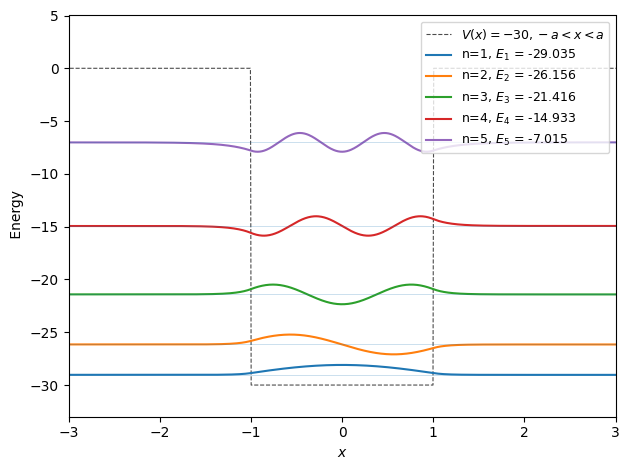

In [94]:
plt.plot(x, V, 'k--', lw=0.8, alpha=0.7, label=r'$ V(x) = -30, -a < x < a $')

for n in range(5):

    plt.plot(x, eigenfunctions[:, n] + evalues[n], label=fr'n={n+1}, $E_{{{n+1}}}$ = {evalues[n]:.3f}')
    plt.axhline(evalues[n], lw=0.4, alpha=0.4)

plt.xlim(-3, 3)
plt.ylim(-V0*1.1, 5)
plt.xlabel(r'$x$')
plt.ylabel(f' Energy')
plt.legend(fontsize=9, loc='upper right')
plt.tight_layout()
plt.show()